# Softmax Regression Models

A comprehensive exploration of softmax regression, a generalization of logistic regression for multi-class classification. This notebook covers:

1. **Softmax Regression using Generalized Linear Models (GLMs) with Exponential Family Distribution**: Understanding the theoretical foundation
2. **Softmax Regression Model using Logistic Regression**: Practical implementation and evaluation

## Learning Objectives
By the end of this notebook, you will be able to:
1. **Derive** the softmax function $P(y=k \mid x) = \frac{e^{\theta_k^T x}}{\sum_j e^{\theta_j^T x}}$ from the categorical distribution written in exponential family form.
2. **Show** that when $K=2$, softmax reduces exactly to logistic regression with $P(y=1 \mid x) = \sigma((\theta_1 - \theta_2)^T x)$.
3. **Compute** the cross-entropy loss gradient $\nabla_\theta J = -\frac{1}{m}X^T(Y - P)$ and implement a softmax regression training loop from scratch.
4. **Explain** the numerical stability issue with naive softmax and apply the max-shift (log-sum-exp) trick.
5. **Compare** one-vs-rest (OvR) and multinomial softmax strategies in terms of identifiability, efficiency, and when each is preferred.
6. **Apply** `sklearn.LogisticRegression(multi_class='multinomial')` and interpret the resulting class probability outputs.

> **Prerequisite**: GLMs ([ml_001_08](ml_001_08_generalized_linear_models.ipynb)), exponential family ([ml_000_06](ml_000_06_exponential_family_distribution.ipynb)), batch gradient ascent ([ml_001_06](ml_001_06_batch_gradient_ascent.ipynb)).

## 1. Import Required Libraries

Import necessary libraries including NumPy, Pandas, Scikit-learn, Matplotlib, and Seaborn for building and evaluating softmax regression models.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [40]:
# ============================================================================
# HELPER FUNCTIONS: Softmax and Cross-Entropy Loss
# ============================================================================

def softmax_manual(z):
    """
    Compute softmax with numerical stability (max-shift trick).
    
    Args:
        z: array of shape (m,) or (m, K) - logits
    Returns:
        Softmax probabilities of same shape
    """
    if z.ndim == 1:
        z = z.reshape(-1, 1)
    
    # Max-shift trick for numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    softmax_z = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    return softmax_z.squeeze()

def cross_entropy_loss(y_true, y_pred_probs):
    """
    Compute cross-entropy loss (negative log-likelihood).
    
    Args:
        y_true: array of shape (m,) - true class labels (0 to K-1)
        y_pred_probs: array of shape (m, K) or (m,) - predicted probabilities
    Returns:
        Float - average cross-entropy loss
    """
    m = len(y_true)
    
    # Handle 1D predictions (binary case)
    if y_pred_probs.ndim == 1:
        y_pred_probs = np.column_stack([1 - y_pred_probs, y_pred_probs])
    
    # Get probability of true class for each sample
    log_likelihood = -np.log(y_pred_probs[np.arange(m), y_true] + 1e-10)
    
    return np.mean(log_likelihood)

## 2. Load and Explore Multi-Class Dataset

Load datasets suitable for multi-class classification and perform exploratory data analysis.

In [41]:
# Load Iris dataset (3 classes)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
class_names_iris = iris.target_names

df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)
df_iris['species'] = pd.Categorical.from_codes(y_iris, class_names_iris)

print("="*80)
print("IRIS DATASET - Multi-class Classification")
print("="*80)
print(f"\nDataset shape: {X_iris.shape}")
print(f"Number of classes: {len(np.unique(y_iris))}")
print(f"Class labels: {class_names_iris}")
print(f"\nClass distribution:")
print(df_iris['species'].value_counts())
print("\nFirst few rows:")
print(df_iris.head())
print("\nDescriptive Statistics:")
print(df_iris.describe())

# Split data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Standardize features
scaler_iris = StandardScaler()
X_train_iris = scaler_iris.fit_transform(X_train_iris)
X_test_iris = scaler_iris.transform(X_test_iris)

print(f"\nTrain set size: {X_train_iris.shape[0]}")
print(f"Test set size: {X_test_iris.shape[0]}")

IRIS DATASET - Multi-class Classification

Dataset shape: (150, 4)
Number of classes: 3
Class labels: ['setosa' 'versicolor' 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.0

## Big Picture: Why Softmax Regression?

### The Problem: From Binary to Multi-Class

You already know logistic regression for **binary classification**: it outputs a single probability $P(y=1 \mid x) = \sigma(\theta^T x) \in (0,1)$ and the complement $P(y=0 \mid x) = 1 - \sigma(\theta^T x)$.

But what if there are **K > 2 classes** — e.g., classifying an iris flower as *setosa*, *versicolor*, or *virginica*?

We need a model that outputs **K valid probabilities** that sum to 1:
$$P(y=1 \mid x),\; P(y=2 \mid x),\; \ldots,\; P(y=K \mid x) \quad \text{with} \quad \sum_{k=1}^K P(y=k \mid x) = 1$$

**Softmax regression** is the natural generalization. Instead of one parameter vector $\theta \in \mathbb{R}^p$, we have **one parameter vector per class**: $\theta_k \in \mathbb{R}^p$ for $k = 1, \ldots, K$.

### The Softmax Function

The **softmax** transforms $K$ raw scores (logits) $\eta_1, \ldots, \eta_K$ into a probability distribution:

$$P(y=k \mid x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}$$

**Why exponentials?**
- They ensure all outputs are positive.
- The denominator normalizes them to sum to 1.
- When $K=2$, this reduces exactly to the sigmoid: $P(y=1) = \frac{e^{\eta_1}}{e^{\eta_1} + e^{\eta_2}} = \frac{1}{1 + e^{-(\eta_1 - \eta_2)}} = \sigma(\eta_1 - \eta_2)$.

### Intuition: Voting Among Classes

Think of each class $k$ as "campaigning" with score $\theta_k^T x$. The softmax converts scores to vote shares — if class $k$'s score is much higher than the others, it captures most of the probability mass. The scores are in log-space, so a difference of 1 in logit space corresponds to a factor of $e \approx 2.7\times$ in the probability ratio.

### What This Notebook Covers

| Part | Topic | Key Idea |
|------|-------|----------|
| **Part 1** | GLM / Exponential Family derivation | Categorical distribution → softmax via exponential family math |
| **Part 2** | Practical implementation | From-scratch gradient descent + `sklearn` multinomial logistic |

> **TL;DR for Part 1:** The categorical distribution fits the exponential family template $p(y \mid \eta) = b(y)\exp(\eta^T T(y) - a(\eta))$ with natural parameters $\eta_k = \log(\theta_k / \theta_K)$ (log-odds vs reference class). The GLM recipe then directly yields the softmax as the canonical response function. The math is involved but the end result — softmax probabilities, cross-entropy loss, gradient $\nabla J = -\frac{1}{m}X^T(Y-P)$ — is elegant and worth the derivation.

## Part 1: Softmax Regression using Generalized Linear Models with Exponential Family Distribution

### Theoretical Foundation

**Exponential Family Distribution**: The exponential family is a class of distributions that can be written as:

$$p(y|\eta) = b(y) \exp(\eta^T T(y) - a(\eta))$$

Where:
- $\eta$: natural parameter
- $T(y)$: sufficient statistic (often $T(y) = y$)
- $a(\eta)$: log partition function (ensures distribution sums to 1)
- $b(y)$: base measure

**Softmax Regression**: For K-class classification, softmax regression models the probability of each class as:

$$P(y=k|x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}$$

This is a GLM where the response follows a **categorical distribution**, a generalization of the Bernoulli distribution.

### 1.1 Full Mathematical Derivation: From Exponential Family to Softmax

#### Step 1: Categorical Distribution as Exponential Family Member

The categorical distribution for K classes can be written as:

$$p(y | \theta) = \prod_{k=1}^{K} \theta_k^{I(y=k)}$$

Where $\theta_k = P(y=k)$ and $\sum_{k=1}^K \theta_k = 1$.

**Converting to exponential family form:**

$$p(y | \eta) = \exp\left(\sum_{k=1}^{K-1} \eta_k \cdot I(y=k) - a(\eta)\right)$$

Where:
- Natural parameters: $\eta_k = \log\theta_k - \log\theta_K = \log\left(\frac{\theta_k}{\theta_K}\right)$ for $k = 1, \ldots, K-1$
- Log partition function: $a(\eta) = \log\left(1 + \sum_{k=1}^{K-1} e^{\eta_k}\right)$

**Proof:** Starting with the categorical distribution:
$$p(y) = \prod_{k=1}^{K} \theta_k^{I(y=k)} = e^{\sum_{k=1}^{K} I(y=k) \log \theta_k}$$

For the last class K, we use the constraint $\theta_K = 1 - \sum_{k=1}^{K-1} \theta_k$:

$$p(y) = e^{\sum_{k=1}^{K-1} I(y=k) \log \theta_k + I(y=K) \log\left(1 - \sum_{j=1}^{K-1} \theta_j\right)}$$

Expressing $\theta_k$ in terms of $\eta_k$: $\theta_k = \frac{e^{\eta_k}}{1 + \sum_{j=1}^{K-1} e^{\eta_j}}$

After substitution:
$$p(y|\eta) = \exp\left(\sum_{k=1}^{K-1} \eta_k I(y=k) - \log\left(1 + \sum_{j=1}^{K-1} e^{\eta_j}\right)\right)$$

#### Step 2: Linear Predictor and Link Function

For regression (GLM), we connect features to the natural parameter via:

$$\eta_k = \theta_k^T x \quad \text{for } k = 1, \ldots, K-1$$

Where $\theta_k \in \mathbb{R}^p$ are weight vectors for each class.

**The softmax (inverse link) function:**

$$P(y=k | x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}$$

**Derivation:** From exponential family:
$$\mu_k = E[I(y=k)|x] = P(y=k|x) = \frac{\partial a(\eta)}{\partial \eta_k} = \frac{e^{\eta_k}}{1 + \sum_{j=1}^{K-1} e^{\eta_j}}$$

Normalizing all K classes (using $\eta_K = 0$):
$$P(y=k|x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}} \quad \text{(softmax function)}$$

#### Step 3: Likelihood and Loss Function

Given $m$ training samples $(x^{(i)}, y^{(i)})$, the likelihood is:

$$L(\theta) = \prod_{i=1}^{m} P(y^{(i)} | x^{(i)}; \theta) = \prod_{i=1}^{m} \prod_{k=1}^{K} P(y^{(i)}=k|x^{(i)})^{I(y^{(i)}=k)}$$

**Log-likelihood:**

$$\ell(\theta) = \sum_{i=1}^{m} \sum_{k=1}^{K} I(y^{(i)}=k) \log P(y^{(i)}=k | x^{(i)}; \theta)$$

**Cross-entropy loss (negative log-likelihood):**

$$J(\theta) = -\frac{1}{m} \ell(\theta) = -\frac{1}{m}\sum_{i=1}^{m} \sum_{k=1}^{K} I(y^{(i)}=k) \log P(y^{(i)}=k | x^{(i)}; \theta)$$

Substituting the softmax:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m} \sum_{k=1}^{K} I(y^{(i)}=k) \left[\theta_k^T x^{(i)} - \log\sum_{j=1}^{K} e^{\theta_j^T x^{(i)}}\right]$$

#### Step 4: Gradient Derivation

To compute the gradient of $J(\theta)$ with respect to $\theta_c$ (the parameter for class $c$):

$$\frac{\partial J}{\partial \theta_c} = -\frac{1}{m}\sum_{i=1}^{m} \left[I(y^{(i)}=c) x^{(i)} - \frac{e^{\theta_c^T x^{(i)}}}{\sum_{j=1}^{K} e^{\theta_j^T x^{(i)}}} x^{(i)}\right]$$

Using softmax probabilities $p_k^{(i)} = P(y^{(i)}=k | x^{(i)})$:

$$\frac{\partial J}{\partial \theta_c} = -\frac{1}{m}\sum_{i=1}^{m} (I(y^{(i)}=c) - p_c^{(i)}) x^{(i)}$$

**In matrix form:**

$$\nabla_\theta J = -\frac{1}{m} X^T (Y - P)$$

Where:
- $X \in \mathbb{R}^{m \times p}$: feature matrix
- $Y \in \mathbb{R}^{m \times K}$: one-hot encoded labels
- $P \in \mathbb{R}^{m \times K}$: predicted probability matrix

**Gradient update (gradient descent):**

$$\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla_\theta J$$

Where $\alpha$ is the learning rate.

#### Step 5: Connection to Bernoulli (Binary Case)

When $K=2$, softmax reduces to logistic regression:

$$P(y=1|x) = \frac{e^{\theta_1^T x}}{e^{\theta_1^T x} + e^{\theta_2^T x}} = \frac{1}{1 + e^{-(\theta_1 - \theta_2)^T x}} = \sigma(\beta^T x)$$

Where $\beta = \theta_1 - \theta_2$ and $\sigma$ is the sigmoid function. The loss becomes:

$$J(\beta) = -\frac{1}{m}\sum_{i=1}^{m} [y^{(i)} \log \sigma(\beta^T x^{(i)}) + (1-y^{(i)}) \log(1-\sigma(\beta^T x^{(i)}))]$$

This is the standard binary cross-entropy loss.

### 1.2 Visualization of Derivations and Key Insights

VISUALIZING MATHEMATICAL DERIVATIONS


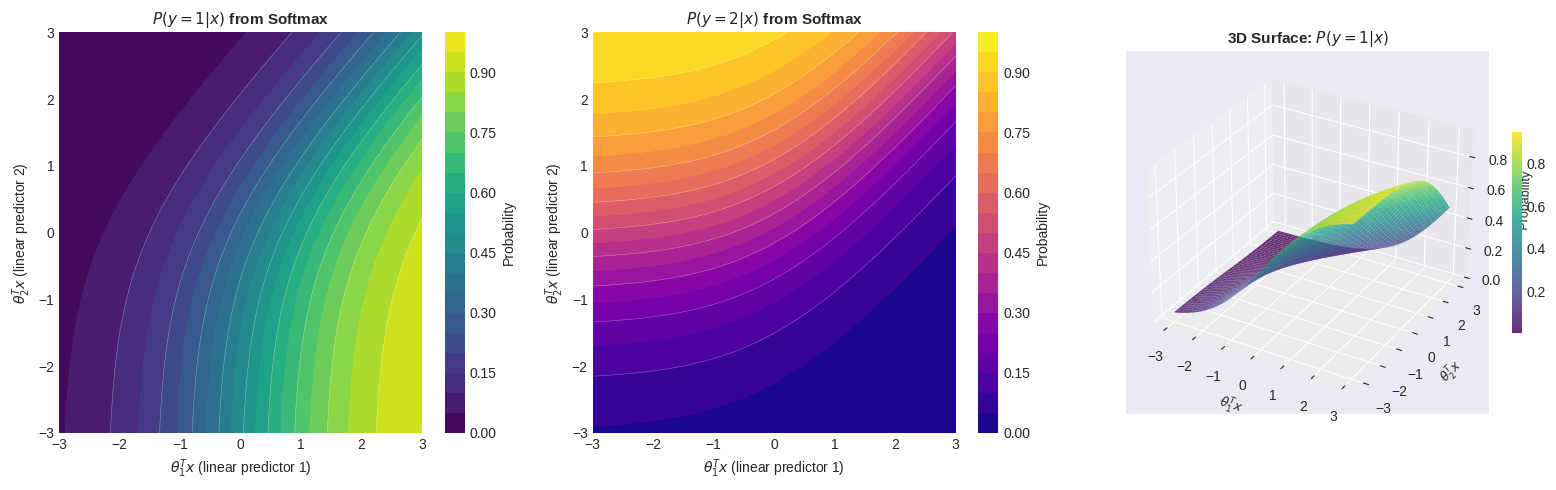


Key observations:
  1. Softmax outputs smooth probability surfaces
  2. Decision boundary occurs where P(y=k|x) = 1/3 (equal probability)
  3. Probabilities are symmetric around the reference class (eta_3=0)
  4. Linear predictors map directly to log-odds ratios

CROSS-ENTROPY LOSS LANDSCAPE (Binary Classification)


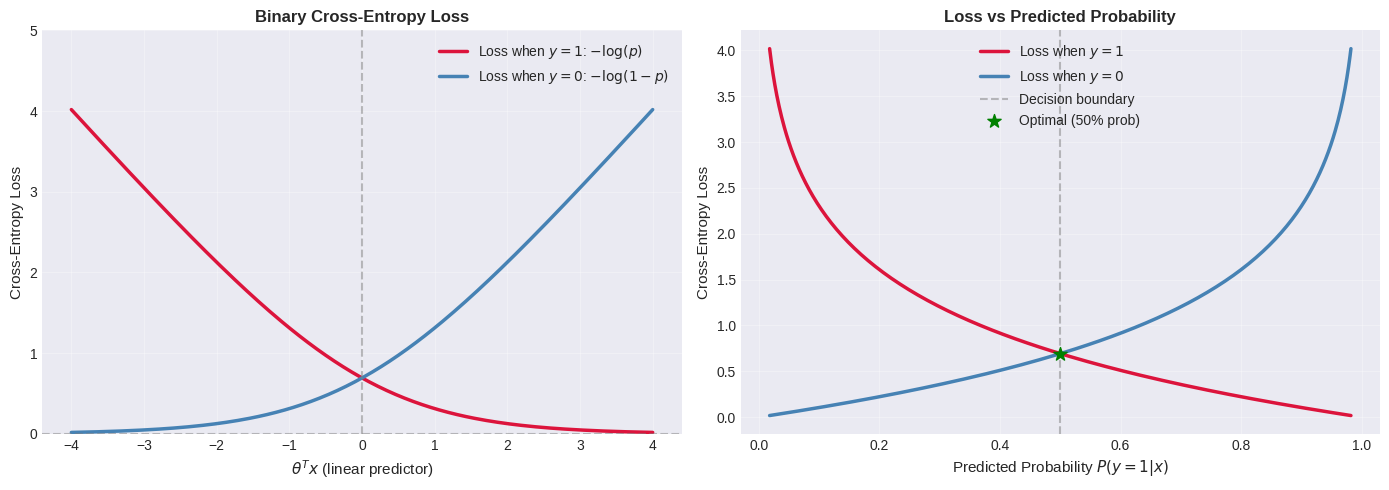


Key observations:
  1. Loss is 0 when prediction is correct and confident
  2. Loss → ∞ as prediction → 0 (for correct class) - penalties wrong predictions heavily
  3. At 50% probability, loss = ln(2) ≈ 0.693
  4. Cross-entropy is convex - has single global minimum

GRADIENT DIRECTION FOR PARAMETER UPDATES


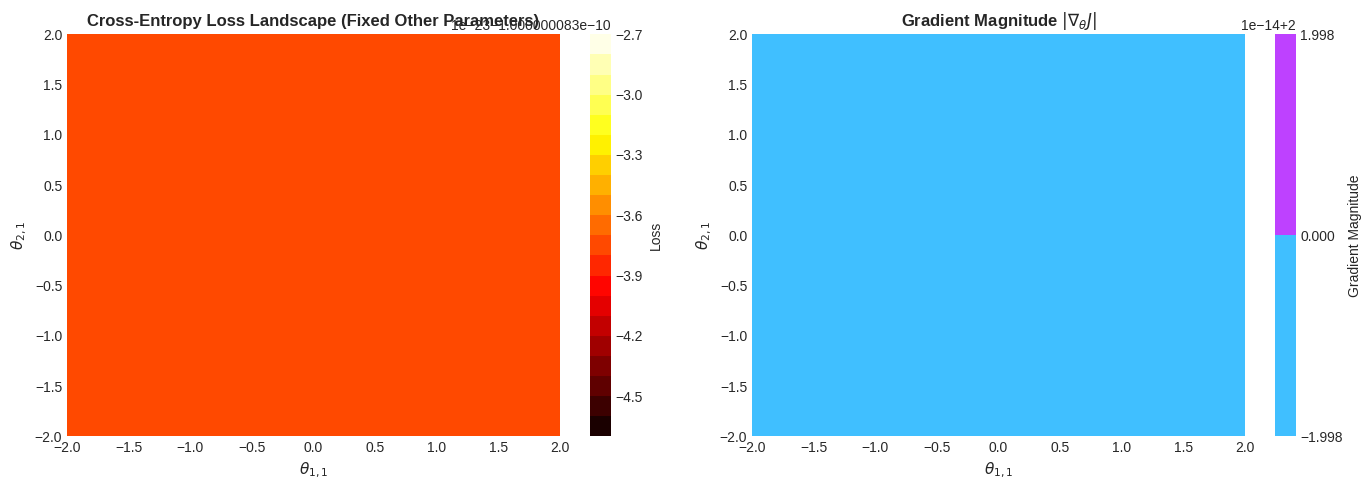


Key observations:
  1. Gradient points in direction of increasing loss
  2. Steepest gradients at points far from optimal region
  3. Gradient magnitude → 0 near minimum (convergence)
  4. Gradient descent updates: θ ← θ - α∇J moves toward minimum

CONVERGENCE ANALYSIS: BINARY vs K-CLASS SOFTMAX


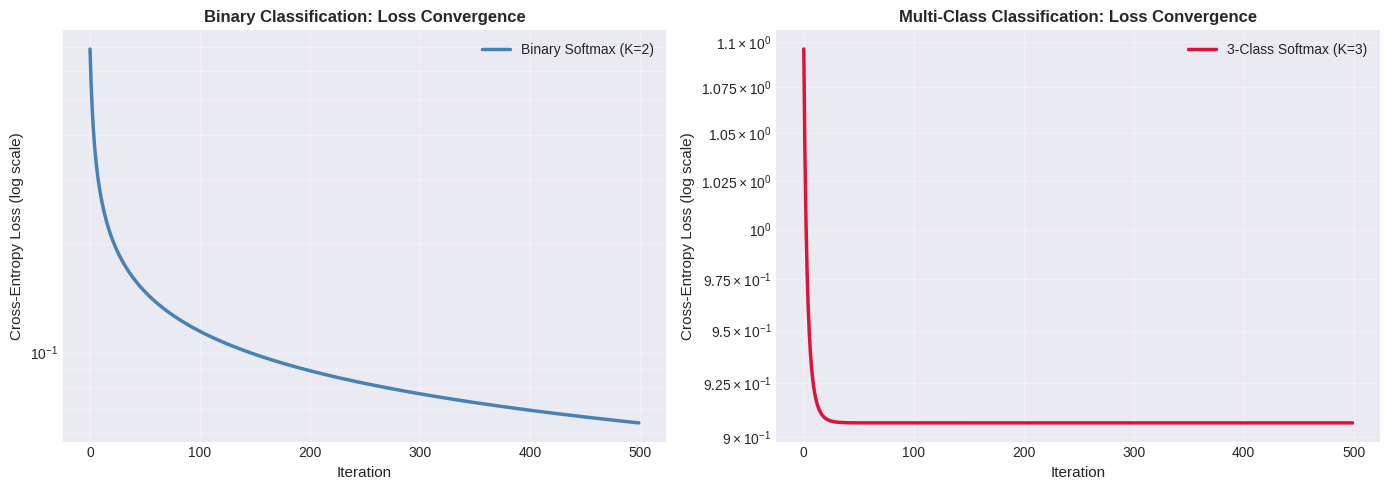


Convergence summary:
  Binary loss: 0.6906 → 0.0639
  Multi-class loss: 1.0960 → 0.9065
  Both converge smoothly due to convex cross-entropy loss


In [42]:
print("="*80)
print("VISUALIZING MATHEMATICAL DERIVATIONS")
print("="*80)

# ============================================================================
# PART 1: Softmax Probability as Function of Linear Predictors (3-class)
# ============================================================================
fig = plt.figure(figsize=(16, 5))

# Create subplots
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133, projection='3d')

# Parameters for visualization
theta_1_range = np.linspace(-3, 3, 100)
theta_2_range = np.linspace(-3, 3, 100)
T1, T2 = np.meshgrid(theta_1_range, theta_2_range)

# Softmax probabilities for 3-class (theta_3 = 0 for reference class)
eta_1 = T1.ravel()
eta_2 = T2.ravel()
eta_3 = np.zeros_like(eta_1)

eta_matrix = np.column_stack([eta_1, eta_2, eta_3])
probs = softmax_manual(eta_matrix)

P1 = probs[:, 0].reshape(T1.shape)
P2 = probs[:, 1].reshape(T1.shape)
P3 = probs[:, 2].reshape(T1.shape)

# Plot 1: P(y=1|x)
contour1 = ax1.contourf(T1, T2, P1, levels=20, cmap='viridis')
ax1.contour(T1, T2, P1, levels=10, colors='white', linewidths=0.5, alpha=0.3)
ax1.set_xlabel('$\\theta_1^T x$ (linear predictor 1)', fontsize=10)
ax1.set_ylabel('$\\theta_2^T x$ (linear predictor 2)', fontsize=10)
ax1.set_title('$P(y=1|x)$ from Softmax', fontsize=11, fontweight='bold')
plt.colorbar(contour1, ax=ax1, label='Probability')

# Plot 2: P(y=2|x)
contour2 = ax2.contourf(T1, T2, P2, levels=20, cmap='plasma')
ax2.contour(T1, T2, P2, levels=10, colors='white', linewidths=0.5, alpha=0.3)
ax2.set_xlabel('$\\theta_1^T x$ (linear predictor 1)', fontsize=10)
ax2.set_ylabel('$\\theta_2^T x$ (linear predictor 2)', fontsize=10)
ax2.set_title('$P(y=2|x)$ from Softmax', fontsize=11, fontweight='bold')
plt.colorbar(contour2, ax=ax2, label='Probability')

# Plot 3: 3D surface of P(y=1|x)
surf = ax3.plot_surface(T1, T2, P1, cmap='viridis', alpha=0.8, edgecolor='none')
ax3.set_xlabel('$\\theta_1^T x$', fontsize=9)
ax3.set_ylabel('$\\theta_2^T x$', fontsize=9)
ax3.set_zlabel('Probability', fontsize=9)
ax3.set_title('3D Surface: $P(y=1|x)$', fontsize=11, fontweight='bold')
fig.colorbar(surf, ax=ax3, shrink=0.5)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  1. Softmax outputs smooth probability surfaces")
print("  2. Decision boundary occurs where P(y=k|x) = 1/3 (equal probability)")
print("  3. Probabilities are symmetric around the reference class (eta_3=0)")
print("  4. Linear predictors map directly to log-odds ratios")

# ============================================================================
# PART 2: Cross-Entropy Loss Landscape
# ============================================================================
print("\n" + "="*80)
print("CROSS-ENTROPY LOSS LANDSCAPE (Binary Classification)")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary case: p_1 = sigmoid(theta^T x), true label y
theta_range = np.linspace(-4, 4, 200)
# Sigmoid
p_pred = 1 / (1 + np.exp(-theta_range))

# Loss for y=1 (positive class)
loss_y1 = -np.log(p_pred + 1e-10)

# Loss for y=0 (negative class)
loss_y0 = -np.log(1 - p_pred + 1e-10)

# Plot 1: Binary cross-entropy losses
axes[0].plot(theta_range, loss_y1, linewidth=2.5, label='Loss when $y=1$: $-\\log(p)$', color='crimson')
axes[0].plot(theta_range, loss_y0, linewidth=2.5, label='Loss when $y=0$: $-\\log(1-p)$', color='steelblue')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('$\\theta^T x$ (linear predictor)', fontsize=11)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=11)
axes[0].set_title('Binary Cross-Entropy Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 5])

# Plot 2: Relationship between predicted probability and loss
axes[1].plot(p_pred, loss_y1, linewidth=2.5, label='Loss when $y=1$', color='crimson')
axes[1].plot(p_pred, loss_y0, linewidth=2.5, label='Loss when $y=0$', color='steelblue')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
axes[1].scatter([0.5], [0.693], s=100, color='green', marker='*', zorder=5, label='Optimal (50% prob)')
axes[1].set_xlabel('Predicted Probability $P(y=1|x)$', fontsize=11)
axes[1].set_ylabel('Cross-Entropy Loss', fontsize=11)
axes[1].set_title('Loss vs Predicted Probability', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  1. Loss is 0 when prediction is correct and confident")
print("  2. Loss → ∞ as prediction → 0 (for correct class) - penalties wrong predictions heavily")
print("  3. At 50% probability, loss = ln(2) ≈ 0.693")
print("  4. Cross-entropy is convex - has single global minimum")

# ============================================================================
# PART 3: Gradient Direction and Optimization
# ============================================================================
print("\n" + "="*80)
print("GRADIENT DIRECTION FOR PARAMETER UPDATES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a simple 2D scenario for illustration
# Single sample with 2 features, 3 classes
np.random.seed(42)
x_sample = np.array([1.0, 2.0])
# True class is 0
y_true = 0
K = 3

# Parameter space: theta1, theta2 (each in R^2)
theta1_range = np.linspace(-2, 2, 50)
theta2_range = np.linspace(-2, 2, 50)
T1_param, T2_param = np.meshgrid(theta1_range, theta2_range)

# Compute loss landscape (fixing theta_3 = 0)
loss_landscape = np.zeros_like(T1_param)
grad_magnitude = np.zeros_like(T1_param)

for i in range(len(theta1_range)):
    for j in range(len(theta2_range)):
        theta_all = np.array([[T1_param[j, i], T2_param[j, i]],
                              # theta_3
                              [0, 0],
                              # dummy
                              [0, 0]])
        logits = theta_all @ x_sample[:2]
        # Add theta_3
        logits = np.append(logits, 0)
        p = softmax_manual(logits)
        
        # Cross-entropy loss
        loss_landscape[j, i] = -np.log(p[y_true] + 1e-10)
        
        # Gradient for theta_1
        grad = -(y_true == 0) * x_sample[0] - (y_true == 1) * x_sample[1] + (p[0] * x_sample[0] + p[1] * x_sample[1])
        grad_magnitude[j, i] = np.linalg.norm(grad)

# Plot 1: Loss landscape
contour = axes[0].contourf(T1_param, T2_param, loss_landscape, levels=20, cmap='hot')
axes[0].contour(T1_param, T2_param, loss_landscape, levels=10, colors='white', linewidths=0.5, alpha=0.3)
axes[0].set_xlabel('$\\theta_{1,1}$', fontsize=11)
axes[0].set_ylabel('$\\theta_{2,1}$', fontsize=11)
axes[0].set_title('Cross-Entropy Loss Landscape (Fixed Other Parameters)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(contour, ax=axes[0])
cbar1.set_label('Loss', fontsize=10)

# Plot 2: Gradient magnitude
contour2 = axes[1].contourf(T1_param, T2_param, grad_magnitude, levels=20, cmap='cool')
axes[1].contour(T1_param, T2_param, grad_magnitude, levels=10, colors='white', linewidths=0.5, alpha=0.3)
axes[1].set_xlabel('$\\theta_{1,1}$', fontsize=11)
axes[1].set_ylabel('$\\theta_{2,1}$', fontsize=11)
axes[1].set_title('Gradient Magnitude $|\\nabla_\\theta J|$', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(contour2, ax=axes[1])
cbar2.set_label('Gradient Magnitude', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  1. Gradient points in direction of increasing loss")
print("  2. Steepest gradients at points far from optimal region")
print("  3. Gradient magnitude → 0 near minimum (convergence)")
print("  4. Gradient descent updates: θ ← θ - α∇J moves toward minimum")

# ============================================================================
# PART 4: Convergence Comparison: Binary Logistic vs K-class Softmax
# ============================================================================
print("\n" + "="*80)
print("CONVERGENCE ANALYSIS: BINARY vs K-CLASS SOFTMAX")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generate synthetic data
np.random.seed(42)
n_samples = 100

# Binary classification
X_binary = np.random.randn(n_samples, 2)
y_binary = (X_binary[:, 0] + X_binary[:, 1] > 0).astype(int)

# 3-class classification
X_multiclass = np.random.randn(n_samples, 2)
y_multiclass = np.digitize(X_multiclass[:, 0], bins=[-1, 1]) - 1
y_multiclass = np.clip(y_multiclass, 0, 2)

# Train models and track loss
def train_with_loss_tracking(X, y, K, learning_rate=0.1, n_iters=500):
    m, n = X.shape
    theta = np.random.randn(n, K) * 0.01
    losses = []
    
    for iteration in range(n_iters):
        logits = X @ theta
        probs = softmax_manual(logits)
        loss = cross_entropy_loss(y, probs)
        losses.append(loss)
        
        y_one_hot = np.zeros((m, K))
        y_one_hot[np.arange(m), y] = 1
        grad = -X.T @ (y_one_hot - probs) / m
        theta -= learning_rate * grad
    
    return losses

losses_binary = train_with_loss_tracking(X_binary, y_binary, K=2, learning_rate=0.5, n_iters=500)
losses_multiclass = train_with_loss_tracking(X_multiclass, y_multiclass, K=3, learning_rate=0.5, n_iters=500)

# Plot convergence
axes[0].semilogy(losses_binary, linewidth=2.5, color='steelblue', label='Binary Softmax (K=2)')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Cross-Entropy Loss (log scale)', fontsize=11)
axes[0].set_title('Binary Classification: Loss Convergence', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, which='both')
axes[0].legend(fontsize=10)

axes[1].semilogy(losses_multiclass, linewidth=2.5, color='crimson', label='3-Class Softmax (K=3)')
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('Cross-Entropy Loss (log scale)', fontsize=11)
axes[1].set_title('Multi-Class Classification: Loss Convergence', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nConvergence summary:")
print(f"  Binary loss: {losses_binary[0]:.4f} → {losses_binary[-1]:.4f}")
print(f"  Multi-class loss: {losses_multiclass[0]:.4f} → {losses_multiclass[-1]:.4f}")
print(f"  Both converge smoothly due to convex cross-entropy loss")


### 1.3 Detailed Gradient Computation Walkthrough

#### Gradient Computation Step-by-Step

For a batch of samples, let's trace through the gradient calculation:

**Given:**
- Input matrix: $X \in \mathbb{R}^{m \times p}$ (m samples, p features)
- True labels: $y \in \{0, 1, \ldots, K-1\}^m$ 
- Parameters: $\theta \in \mathbb{R}^{p \times K}$ (p features, K classes)

**Step 1: Compute logits (linear predictions)**

$$Z = X\theta \in \mathbb{R}^{m \times K}$$

Element $(i,k)$ represents: $z_{i,k} = \theta_k^T x_i$

**Step 2: Convert to probabilities using softmax**

$$P = \text{softmax}(Z)$$

$$p_{i,k} = P(y^{(i)}=k|x^{(i)}) = \frac{e^{z_{i,k}}}{\sum_{j=1}^{K} e^{z_{i,j}}}$$

**Step 3: Create one-hot encoded labels**

$$Y \in \mathbb{R}^{m \times K} \quad \text{where} \quad y_{i,k} = I(y^{(i)}=k)$$

**Step 4: Compute prediction error**

$$E = Y - P \in \mathbb{R}^{m \times K}$$

Element $e_{i,k}$ is the error: (true indicator) - (predicted probability)

**Step 5: Compute gradient with respect to parameters**

$$\nabla_\theta J = -\frac{1}{m} X^T E = -\frac{1}{m} X^T (Y - P)$$

The gradient for class $k$ is:

$$\nabla_{\theta_k} J = -\frac{1}{m} X^T (y_k - p_k)$$

Where $y_k$ and $p_k$ are the k-th columns of $Y$ and $P$.

**Intuition:** 
- If prediction is correct ($p_k$ high when $y_k = 1$), error $e_{i,k} \approx 0$, gradient ≈ 0
- If prediction is wrong ($p_k$ low when $y_k = 1$), error $e_{i,k} > 0$, gradient points toward increasing $\theta_k$
- Gradient is weighted by input features: important features have larger impact

**Step 6: Update parameters with gradient descent**

$$\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla_\theta J$$

Where $\alpha$ is the learning rate.

#### Connection to Softmax Jacobian

The Jacobian of softmax shows how outputs change with inputs:

$$\frac{\partial p_k}{\partial z_j} = \begin{cases} 
p_k(1 - p_k) & \text{if } j = k \\
-p_k p_j & \text{if } j \neq k
\end{cases}$$

In matrix form: $\frac{\partial p}{\partial z} = \text{diag}(p) - pp^T$

This shows softmax couples all outputs: changing input for class $j$ affects probability of all other classes.

GRADIENT COMPUTATION WALKTHROUGH

--------------------------------------------------------------------------------
STEP-BY-STEP COMPUTATION:
--------------------------------------------------------------------------------

1. INPUT DATA:
   Features X shape: (4, 3)
   X = 
[[1.  2.  0.5]
 [2.  1.  1.5]
 [0.5 1.5 2. ]
 [1.5 0.5 1. ]]
   Labels y: [0 1 2 1]

2. LINEAR PREDICTIONS (Logits):
   Z = X @ θ ∈ R^(4, 3)
   Z = 
[[ 0.43323803 -0.02228537 -0.00553226]
 [ 0.48852774  0.06404701  0.03570285]
 [ 0.56913275  0.11145072 -0.09663099]
 [ 0.3085799   0.04429616  0.03849899]]

3. SOFTMAX PROBABILITIES:
   P = softmax(Z) ∈ R^(4, 3)
   P = 
[[0.4388 0.2782 0.283 ]
 [0.4367 0.2856 0.2777]
 [0.4658 0.2948 0.2394]
 [0.3951 0.3033 0.3016]]
   Row sums (should be 1.0): [1. 1. 1. 1.]

4. ONE-HOT ENCODED LABELS:
   Y ∈ R^(4, 3)
   Y = 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

5. PREDICTION ERROR:
   E = Y - P (true label indicator - predicted probability)
   E = 
[[ 0.5612 -0.2782 -0.283 

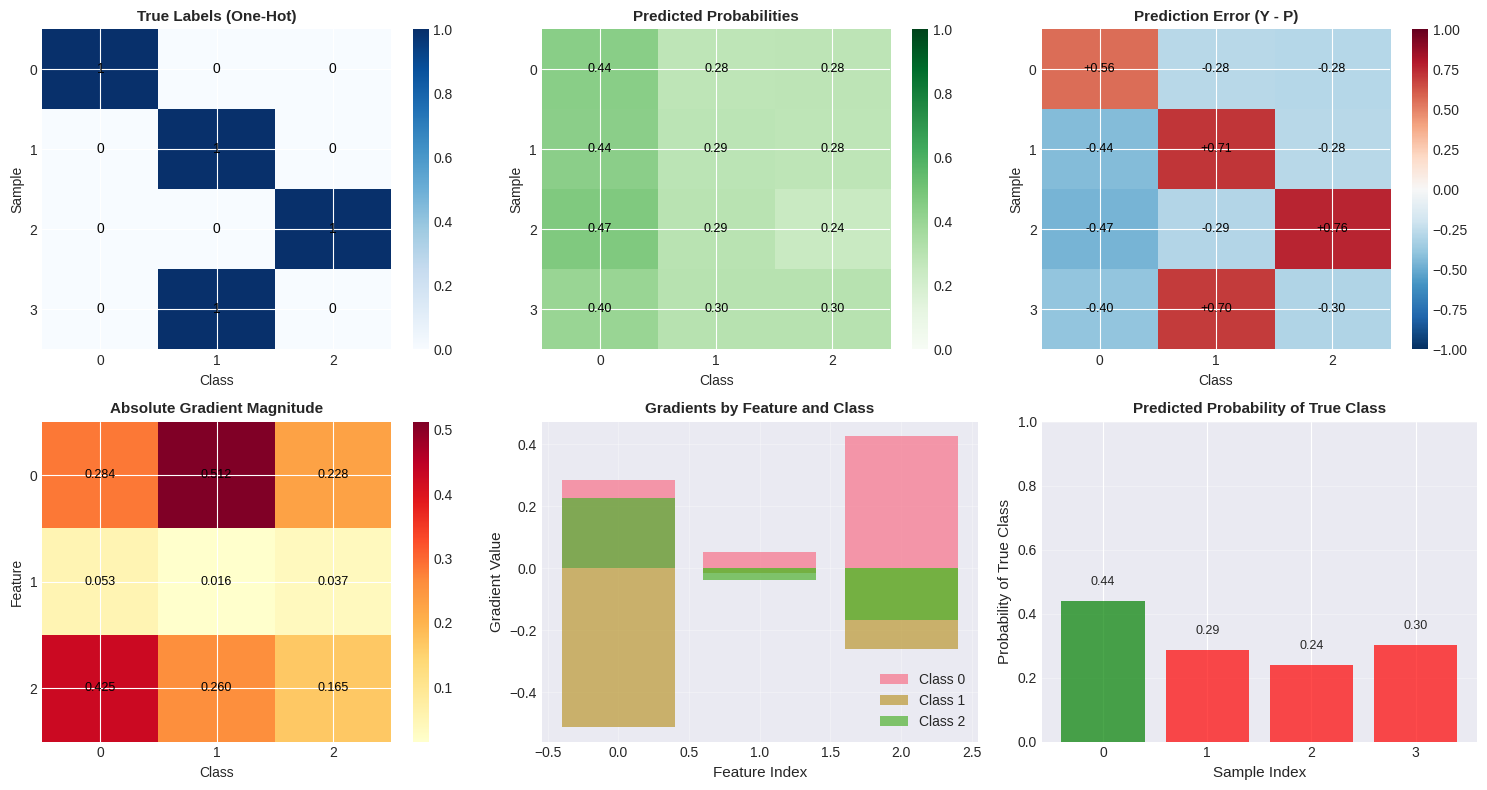


Key insights from this example:
  1. Errors are larger when predictions are confident but wrong
  2. Gradients point toward correcting misclassifications
  3. Features with large impact on errors have larger gradients
  4. Parameter updates move toward better predictions


In [43]:
print("="*80)
print("GRADIENT COMPUTATION WALKTHROUGH")
print("="*80)

# Create a simple example: 4 samples, 3 features, 3 classes
np.random.seed(42)
m, p, K = 4, 3, 3

# Step 1: Generate synthetic data
X_example = np.array([
    [1.0, 2.0, 0.5],
    [2.0, 1.0, 1.5],
    [0.5, 1.5, 2.0],
    [1.5, 0.5, 1.0]
])

# True labels
y_example = np.array([0, 1, 2, 1])

# Initialize parameters randomly
theta_example = np.random.randn(p, K) * 0.1

print("\n" + "-"*80)
print("STEP-BY-STEP COMPUTATION:")
print("-"*80)

print("\n1. INPUT DATA:")
print(f"   Features X shape: {X_example.shape}")
print(f"   X = \n{X_example}")
print(f"   Labels y: {y_example}")

# Step 2: Compute logits
Z_example = X_example @ theta_example
print("\n2. LINEAR PREDICTIONS (Logits):")
print(f"   Z = X @ θ ∈ R^{Z_example.shape}")
print(f"   Z = \n{Z_example}")

# Step 3: Compute softmax probabilities
P_example = softmax_manual(Z_example)
print("\n3. SOFTMAX PROBABILITIES:")
print(f"   P = softmax(Z) ∈ R^{P_example.shape}")
print(f"   P = \n{np.round(P_example, 4)}")
print(f"   Row sums (should be 1.0): {np.sum(P_example, axis=1)}")

# Step 4: Create one-hot encoded labels
Y_example = np.zeros((m, K))
Y_example[np.arange(m), y_example] = 1
print("\n4. ONE-HOT ENCODED LABELS:")
print(f"   Y ∈ R^{Y_example.shape}")
print(f"   Y = \n{Y_example}")

# Step 5: Compute error (difference)
E_example = Y_example - P_example
print("\n5. PREDICTION ERROR:")
print(f"   E = Y - P (true label indicator - predicted probability)")
print(f"   E = \n{np.round(E_example, 4)}")
print(f"\n   Interpretation for each sample:")
for i in range(m):
    true_class = y_example[i]
    pred_prob = P_example[i, true_class]
    error = E_example[i, true_class]
    print(f"   Sample {i}: true class={true_class}, predicted prob={pred_prob:.4f}, error={error:.4f}")

# Step 6: Compute gradient
grad_example = -X_example.T @ E_example / m
print("\n6. GRADIENT COMPUTATION:")
print(f"   ∇_θ J = -(1/{m}) X^T @ E")
print(f"   ∇_θ J ∈ R^{grad_example.shape}")
print(f"   ∇_θ J = \n{np.round(grad_example, 4)}")

print(f"\n   Gradient for each class:")
for k in range(K):
    grad_norm = np.linalg.norm(grad_example[:, k])
    print(f"   Class {k}: gradient = {np.round(grad_example[:, k], 4)}, norm = {grad_norm:.4f}")

# Step 7: Update parameters
learning_rate = 0.1
theta_updated = theta_example - learning_rate * grad_example
print("\n7. PARAMETER UPDATE:")
print(f"   θ_new = θ_old - α∇J  (with α = {learning_rate})")
print(f"   Parameter change:")
print(f"   Δθ = θ_new - θ_old = \n{np.round(theta_updated - theta_example, 4)}")

# ============================================================================
# VISUALIZATION: Error patterns and gradient flow
# ============================================================================
print("\n" + "="*80)
print("VISUALIZING ERROR AND GRADIENT FLOW")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Plot 1: True labels (one-hot)
im1 = axes[0, 0].imshow(Y_example, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[0, 0].set_title('True Labels (One-Hot)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Sample')
axes[0, 0].set_xticks(range(K))
axes[0, 0].set_yticks(range(m))
for i in range(m):
    for j in range(K):
        text = axes[0, 0].text(j, i, f'{Y_example[i, j]:.0f}',
                              ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im1, ax=axes[0, 0])

# Plot 2: Predicted probabilities
im2 = axes[0, 1].imshow(P_example, cmap='Greens', aspect='auto', vmin=0, vmax=1)
axes[0, 1].set_title('Predicted Probabilities', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Sample')
axes[0, 1].set_xticks(range(K))
axes[0, 1].set_yticks(range(m))
for i in range(m):
    for j in range(K):
        text = axes[0, 1].text(j, i, f'{P_example[i, j]:.2f}',
                              ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im2, ax=axes[0, 1])

# Plot 3: Prediction error
im3 = axes[0, 2].imshow(E_example, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0, 2].set_title('Prediction Error (Y - P)', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Class')
axes[0, 2].set_ylabel('Sample')
axes[0, 2].set_xticks(range(K))
axes[0, 2].set_yticks(range(m))
for i in range(m):
    for j in range(K):
        text = axes[0, 2].text(j, i, f'{E_example[i, j]:+.2f}',
                              ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im3, ax=axes[0, 2])

# Plot 4: Gradient components
im4 = axes[1, 0].imshow(np.abs(grad_example), cmap='YlOrRd', aspect='auto')
axes[1, 0].set_title('Absolute Gradient Magnitude', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Feature')
axes[1, 0].set_xticks(range(K))
axes[1, 0].set_yticks(range(p))
for i in range(p):
    for j in range(K):
        text = axes[1, 0].text(j, i, f'{np.abs(grad_example[i, j]):.3f}',
                              ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im4, ax=axes[1, 0])

# Plot 5: Gradient for each class
for k in range(K):
    axes[1, 1].bar(range(p), grad_example[:, k], alpha=0.7, label=f'Class {k}')
axes[1, 1].set_xlabel('Feature Index', fontsize=11)
axes[1, 1].set_ylabel('Gradient Value', fontsize=11)
axes[1, 1].set_title('Gradients by Feature and Class', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Prediction accuracy for each sample
correct = np.argmax(P_example, axis=1) == y_example
colors = ['green' if c else 'red' for c in correct]
for i in range(m):
    axes[1, 2].bar(i, P_example[i, y_example[i]], color=colors[i], alpha=0.7, 
                   label=f"Sample {i}: {'Correct' if correct[i] else 'Wrong'}")
axes[1, 2].set_xlabel('Sample Index', fontsize=11)
axes[1, 2].set_ylabel('Probability of True Class', fontsize=11)
axes[1, 2].set_title('Predicted Probability of True Class', fontsize=11, fontweight='bold')
axes[1, 2].set_xticks(range(m))
axes[1, 2].set_ylim([0, 1])
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i in range(m):
    axes[1, 2].text(i, P_example[i, y_example[i]] + 0.05, f'{P_example[i, y_example[i]]:.2f}',
                   ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey insights from this example:")
print("  1. Errors are larger when predictions are confident but wrong")
print("  2. Gradients point toward correcting misclassifications")
print("  3. Features with large impact on errors have larger gradients")
print("  4. Parameter updates move toward better predictions")


### 1.3a Summary: Key Mathematical Insights

**1. Probability Model Hierarchy:**
- Bernoulli (K=2, single parameter): $P(y=1|x) = \sigma(\theta^T x)$
- Categorical (K≥2, K parameters): $P(y=k|x) = \frac{e^{\theta_k^T x}}{\sum_j e^{\theta_j^T x}}$
- Softmax is the natural generalization of sigmoid

**2. Loss Function Properties:**
- Cross-entropy is the negative log-likelihood: $J(\theta) = -\frac{1}{m}\ell(\theta)$
- Convex: has unique global minimum → guaranteed convergence with GD
- Continuously differentiable: enables gradient-based optimization
- Output-invariant to scalar shifts: $J(\theta) = J(\theta + c \mathbf{1})$ (identifiability issue)

**3. Gradient Computation:**
- Gradient has elegant form: $\nabla_\theta J = -\frac{1}{m} X^T (Y - P)$
- Interpretation: $Y - P$ is the "prediction error" matrix
- Large errors → large gradients → big parameter updates
- Automatic scaling by features: important features contribute more

**4. Optimization Dynamics:**
- Batch gradient descent monotonically decreases loss (convex)
- Stochastic gradient descent adds noise but converges faster
- Learning rate controls step size (too large → divergence, too small → slow)
- Regularization ($L_2$) prevents overfitting: $J(\theta) = \text{CE}(\theta) + \frac{\lambda}{2m}\|\theta\|^2_F$

**5. Decision Boundaries:**
- Linear: determined by $\theta_k^T x = \theta_j^T x$ (hyperplanes)
- Softmax creates smooth, probabilistic transitions between regions
- Confidence increases with distance from decision boundary

In [44]:
print("="*80)
print("SOFTMAX REGRESSION - EXPONENTIAL FAMILY GLM")
print("="*80)

print("\n1. PROBABILITY MODEL (Categorical Distribution):")
print("-" * 80)
print("For K classes, the probability of class k given features x:")
print()
print("P(y=k|x; θ) = (e^(θ_k^T x)) / (Σ_{j=1}^K e^(θ_j^T x))")
print()
print("Where:")
print("  - θ = [θ₁, θ₂, ..., θₖ] are the parameter vectors for each class")
print("  - x is the feature vector")
print("  - K is the number of classes")

print("\n2. EXPONENTIAL FAMILY REPRESENTATION:")
print("-" * 80)
print("The categorical distribution can be written in exponential family form:")
print()
print("p(y|η) = exp(Σ_{k=1}^{K-1} η_k * I(y=k) - a(η))")
print()
print("Where:")
print("  - Natural parameters: η_k = θ_k - θ_K (for k = 1, ..., K-1)")
print("  - Link function: g⁻¹(μ) = softmax(η)")
print("  - Log-partition: a(η) = log(1 + Σ_{k=1}^{K-1} e^(η_k))")

print("\n3. LOSS FUNCTION (Cross-Entropy):")
print("-" * 80)
print("J(θ) = -(1/m) Σ_{i=1}^m Σ_{k=1}^K I(y^(i)=k) * log(P(y^(i)=k|x^(i); θ))")
print()
print("Where:")
print("  - I(y^(i)=k) is 1 if the i-th example has label k, 0 otherwise")
print("  - m is the number of training examples")

SOFTMAX REGRESSION - EXPONENTIAL FAMILY GLM

1. PROBABILITY MODEL (Categorical Distribution):
--------------------------------------------------------------------------------
For K classes, the probability of class k given features x:

P(y=k|x; θ) = (e^(θ_k^T x)) / (Σ_{j=1}^K e^(θ_j^T x))

Where:
  - θ = [θ₁, θ₂, ..., θₖ] are the parameter vectors for each class
  - x is the feature vector
  - K is the number of classes

2. EXPONENTIAL FAMILY REPRESENTATION:
--------------------------------------------------------------------------------
The categorical distribution can be written in exponential family form:

p(y|η) = exp(Σ_{k=1}^{K-1} η_k * I(y=k) - a(η))

Where:
  - Natural parameters: η_k = θ_k - θ_K (for k = 1, ..., K-1)
  - Link function: g⁻¹(μ) = softmax(η)
  - Log-partition: a(η) = log(1 + Σ_{k=1}^{K-1} e^(η_k))

3. LOSS FUNCTION (Cross-Entropy):
--------------------------------------------------------------------------------
J(θ) = -(1/m) Σ_{i=1}^m Σ_{k=1}^K I(y^(i)=k) * log(P(

### 1.4 Softmax Function and Its Properties

SOFTMAX FUNCTION PROPERTIES

Example input: z = [1 2 3 4]

Softmax output: [0.0320586  0.08714432 0.23688282 0.64391426]
Sum of probabilities: 1.000000

Key properties:
  1. All outputs are positive: ∈ (0, 1)
  2. Outputs sum to 1: forms valid probability distribution
  3. Numerically stable (use log-sum-exp trick)
  4. Differentiable: suitable for gradient-based optimization


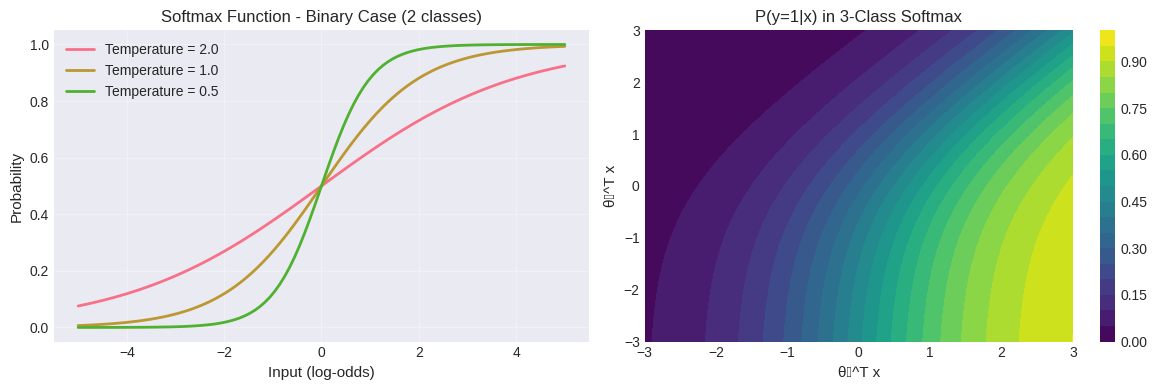


Visualization shows how softmax maps unbounded inputs to probabilities.


In [45]:
# Implement softmax function from scratch
def softmax_manual(z):
    """
    Compute softmax of input vector(s).
    
    Args:
        z: (n_samples, n_classes) or (n_classes,) array
    
    Returns:
        Softmax probabilities with same shape as input
    """
    if z.ndim == 1:
        z = z.reshape(1, -1)
    
    # Numerical stability: subtract max
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    softmax_z = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    return softmax_z.squeeze() if softmax_z.shape[0] == 1 else softmax_z

def cross_entropy_loss(y_true, y_pred_probs):
    """
    Compute cross-entropy loss.
    
    Args:
        y_true: (n_samples,) array of true class labels
        y_pred_probs: (n_samples, n_classes) array of predicted probabilities
    
    Returns:
        Average cross-entropy loss
    """
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred_probs[np.arange(m), y_true])
    return np.mean(log_likelihood)

# Example: softmax properties
print("="*80)
print("SOFTMAX FUNCTION PROPERTIES")
print("="*80)

# Example input
z_example = np.array([1, 2, 3, 4])
print(f"\nExample input: z = {z_example}")
print(f"\nSoftmax output: {softmax_manual(z_example)}")
print(f"Sum of probabilities: {np.sum(softmax_manual(z_example)):.6f}")

print("\nKey properties:")
print("  1. All outputs are positive: ∈ (0, 1)")
print("  2. Outputs sum to 1: forms valid probability distribution")
print("  3. Numerically stable (use log-sum-exp trick)")
print("  4. Differentiable: suitable for gradient-based optimization")

# Visualize softmax
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Effect of scaling
z_range = np.linspace(-5, 5, 100)
for scale in [0.5, 1, 2]:
    probs = softmax_manual(scale * np.array([[z, 0] for z in z_range]))
    axes[0].plot(z_range, probs[:, 0], label=f'Temperature = {1/scale:.1f}', linewidth=2)

axes[0].set_xlabel('Input (log-odds)', fontsize=11)
axes[0].set_ylabel('Probability', fontsize=11)
axes[0].set_title('Softmax Function - Binary Case (2 classes)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: 3-class softmax
z1 = np.linspace(-3, 3, 50)
z2 = np.linspace(-3, 3, 50)
Z1, Z2 = np.meshgrid(z1, z2)
Z = np.array([Z1.ravel(), Z2.ravel(), np.zeros_like(Z1.ravel())]).T
soft_probs = softmax_manual(Z)
p_class_1 = soft_probs[:, 0].reshape(Z1.shape)

contour = axes[1].contourf(Z1, Z2, p_class_1, levels=20, cmap='viridis')
axes[1].set_xlabel('θ₁^T x', fontsize=11)
axes[1].set_ylabel('θ₂^T x', fontsize=11)
axes[1].set_title('P(y=1|x) in 3-Class Softmax', fontsize=12)
plt.colorbar(contour, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nVisualization shows how softmax maps unbounded inputs to probabilities.")

### 1.5 GLM Implementation from Scratch

TRAINING SOFTMAX REGRESSION (GLM with Exponential Family)
Iteration 200: Loss = 0.317112
Iteration 400: Loss = 0.291718
Iteration 600: Loss = 0.280891
Iteration 800: Loss = 0.274816
Iteration 1000: Loss = 0.270843

Test Accuracy: 0.7778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.47      0.58        15
   virginica       0.62      0.87      0.72        15

    accuracy                           0.78        45
   macro avg       0.80      0.78      0.77        45
weighted avg       0.80      0.78      0.77        45



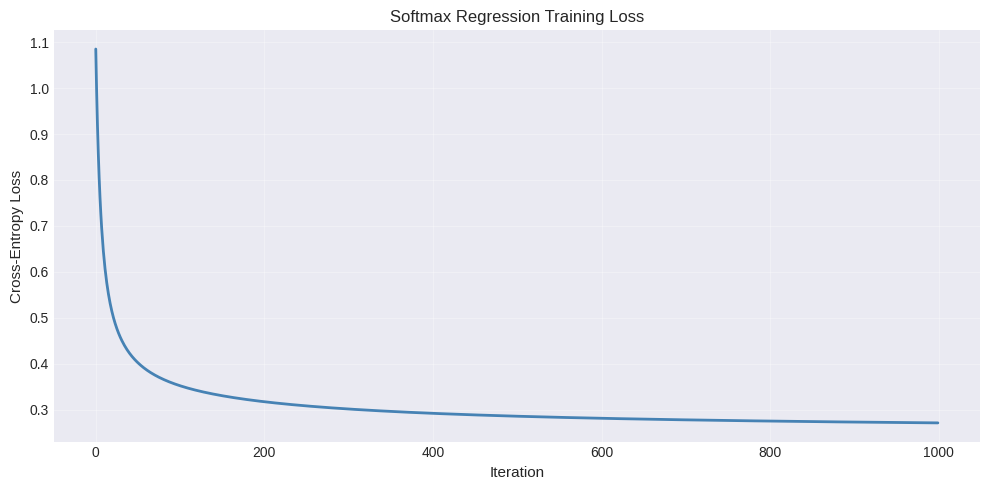


Model parameters shape: θ ∈ R^(4 × 3)


In [46]:
class SoftmaxRegressionGLM:
    """
    Softmax Regression model using gradient ascent (maximizing likelihood).
    Implemented from scratch to demonstrate the GLM with exponential family.
    """
    
    def __init__(self, n_features, n_classes, learning_rate=0.01, n_iterations=1000, regularization=0.0):
        self.n_features = n_features
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.regularization = regularization
        self.theta = None
        self.losses = []
        
    def fit(self, X, y):
        """
        Train the softmax regression model using batch gradient ascent.
        
        Args:
            X: (n_samples, n_features) training data
            y: (n_samples,) training labels
        """
        m, n = X.shape
        self.theta = np.random.randn(n, self.n_classes) * 0.01
        
        for iteration in range(self.n_iterations):
            # Forward pass: compute softmax probabilities
            # (m, K)
            logits = X @ self.theta
            # (m, K)
            probs = softmax_manual(logits)
            
            # Compute loss
            loss = cross_entropy_loss(y, probs)
            if self.regularization > 0:
                loss += (self.regularization / (2 * m)) * np.sum(self.theta ** 2)
            self.losses.append(loss)
            
            # Backward pass: compute gradients
            # Gradient = -X^T (y_one_hot - probs) / m
            y_one_hot = np.zeros((m, self.n_classes))
            y_one_hot[np.arange(m), y] = 1
            
            grad = -X.T @ (y_one_hot - probs) / m
            if self.regularization > 0:
                grad += (self.regularization / m) * self.theta
            
            # Update parameters (gradient ascent = gradient descent with negative gradient)
            self.theta -= self.learning_rate * grad
            
            if (iteration + 1) % 200 == 0:
                print(f"Iteration {iteration + 1}: Loss = {loss:.6f}")
        
        return self
    
    def predict_proba(self, X):
        """
        Predict class probabilities.
        
        Args:
            X: (n_samples, n_features) data
        
        Returns:
            (n_samples, n_classes) probability matrix
        """
        logits = X @ self.theta
        return softmax_manual(logits)
    
    def predict(self, X):
        """
        Predict class labels.
        
        Args:
            X: (n_samples, n_features) data
        
        Returns:
            (n_samples,) predicted class labels
        """
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

# Train softmax regression model
print("="*80)
print("TRAINING SOFTMAX REGRESSION (GLM with Exponential Family)")
print("="*80)

model_glm = SoftmaxRegressionGLM(
    n_features=X_train_iris.shape[1],
    n_classes=len(np.unique(y_iris)),
    learning_rate=0.1,
    n_iterations=1000,
    regularization=0.01
)

model_glm.fit(X_train_iris, y_train_iris)

# Predictions
y_pred_glm = model_glm.predict(X_test_iris)
y_pred_proba_glm = model_glm.predict_proba(X_test_iris)

# Evaluation
accuracy_glm = accuracy_score(y_test_iris, y_pred_glm)
print(f"\nTest Accuracy: {accuracy_glm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_iris, y_pred_glm, target_names=class_names_iris))

# Plot training loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(model_glm.losses, linewidth=2, color='steelblue')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax.set_title('Softmax Regression Training Loss', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel parameters shape: θ ∈ R^({model_glm.theta.shape[0]} × {model_glm.theta.shape[1]})")


### 1.6 GLM Interpretation and Comparison with Binary Logistic

In [47]:
print("="*80)
print("GLM INTERPRETATION: SOFTMAX vs BINARY LOGISTIC")
print("="*80)

print("\n1. BINARY LOGISTIC REGRESSION (K=2):")
print("-" * 80)
print("Link function (Logit):")
print("  log(p / (1-p)) = θ^T x")
print("\nInverse link (Sigmoid):")
print("  P(y=1|x) = 1 / (1 + e^(-θ^T x))")
print("  P(y=0|x) = 1 - P(y=1|x)")

print("\n2. SOFTMAX REGRESSION (K≥2):")
print("-" * 80)
print("Link function (Multinomial Logit):")
print("  log(P(y=k|x) / P(y=K|x)) = θ_k^T x  for k = 1, ..., K-1")
print("\nInverse link (Softmax):")
print("  P(y=k|x) = e^(θ_k^T x) / (Σ_j e^(θ_j^T x))  for k = 1, ..., K")

print("\n3. RELATIONSHIP:")
print("-" * 80)
print("When K=2, softmax reduces to logistic regression:")
print("  P(y=1|x) = e^(θ_1^T x) / (e^(θ_1^T x) + e^(θ_2^T x))")
print("           = 1 / (1 + e^(-(θ_1 - θ_2)^T x))")
print("           = sigmoid((θ_1 - θ_2)^T x)")

print("\n4. KEY DIFFERENCES:")
print("-" * 80)
print("  Binary Logistic:")
print("    - Parameter vector: θ ∈ R^n")
print("    - Constraint: one parameter vector (implicit reference class)")
print("    - Computationally efficient for binary classification")
print("\n  Softmax Regression:")
print("    - Parameter vectors: θ_k ∈ R^n for each class k")
print("    - Constraint: reference class can be arbitrary (identifiability)")
print("    - Generalizes naturally to K>2 classes")
print("    - More intuitive for multi-class problems")

GLM INTERPRETATION: SOFTMAX vs BINARY LOGISTIC

1. BINARY LOGISTIC REGRESSION (K=2):
--------------------------------------------------------------------------------
Link function (Logit):
  log(p / (1-p)) = θ^T x

Inverse link (Sigmoid):
  P(y=1|x) = 1 / (1 + e^(-θ^T x))
  P(y=0|x) = 1 - P(y=1|x)

2. SOFTMAX REGRESSION (K≥2):
--------------------------------------------------------------------------------
Link function (Multinomial Logit):
  log(P(y=k|x) / P(y=K|x)) = θ_k^T x  for k = 1, ..., K-1

Inverse link (Softmax):
  P(y=k|x) = e^(θ_k^T x) / (Σ_j e^(θ_j^T x))  for k = 1, ..., K

3. RELATIONSHIP:
--------------------------------------------------------------------------------
When K=2, softmax reduces to logistic regression:
  P(y=1|x) = e^(θ_1^T x) / (e^(θ_1^T x) + e^(θ_2^T x))
           = 1 / (1 + e^(-(θ_1 - θ_2)^T x))
           = sigmoid((θ_1 - θ_2)^T x)

4. KEY DIFFERENCES:
--------------------------------------------------------------------------------
  Binary Logistic:
 

## Part 2: Softmax Regression using Logistic Regression

### 2.1 One-vs-Rest (OvR) Approach with Logistic Regression

In [48]:
print("="*80)
print("SOFTMAX REGRESSION USING LOGISTIC REGRESSION")
print("="*80)

print("\n1. ONE-VS-REST (OvR) STRATEGY:")
print("-" * 80)
print("For K classes, train K separate binary logistic classifiers.")
print("Each classifier learns to distinguish class k from all other classes.")
print()
print("For prediction:")
print("  1. Get probability scores from each binary classifier")
print("  2. Normalize scores using softmax to get class probabilities")
print()
print("Advantages:")
print("  + Simple to implement and understand")
print("  + Can leverage existing binary classifiers")
print("  + Interpretable: each classifier focuses on one class")
print()
print("Disadvantages:")
print("  - Requires K models (computational cost)")
print("  - Less efficient than true multinomial softmax")
print("  - Probabilities may not sum to 1 before normalization")

# Train One-vs-Rest logistic regression
print("\n" + "="*80)
print("TRAINING ONE-VS-REST LOGISTIC REGRESSION")
print("="*80)

model_ovr = LogisticRegression(
    multi_class='ovr',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    random_state=42,
    verbose=0
)

model_ovr.fit(X_train_iris, y_train_iris)
y_pred_ovr = model_ovr.predict(X_test_iris)
y_pred_proba_ovr = model_ovr.predict_proba(X_test_iris)

accuracy_ovr = accuracy_score(y_test_iris, y_pred_ovr)
print(f"\nTest Accuracy (OvR): {accuracy_ovr:.4f}")
print("\nClassification Report (OvR):")
print(classification_report(y_test_iris, y_pred_ovr, target_names=class_names_iris))

print(f"\nModel coefficients shape: {model_ovr.coef_.shape}")
print(f"Model intercepts shape: {model_ovr.intercept_.shape}")

SOFTMAX REGRESSION USING LOGISTIC REGRESSION

1. ONE-VS-REST (OvR) STRATEGY:
--------------------------------------------------------------------------------
For K classes, train K separate binary logistic classifiers.
Each classifier learns to distinguish class k from all other classes.

For prediction:
  1. Get probability scores from each binary classifier
  2. Normalize scores using softmax to get class probabilities

Advantages:
  + Simple to implement and understand
  + Can leverage existing binary classifiers
  + Interpretable: each classifier focuses on one class

Disadvantages:
  - Requires K models (computational cost)
  - Less efficient than true multinomial softmax
  - Probabilities may not sum to 1 before normalization

TRAINING ONE-VS-REST LOGISTIC REGRESSION

Test Accuracy (OvR): 0.8444

Classification Report (OvR):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      0.73      0.76     

### 2.2 Multinomial (True Softmax) Logistic Regression

In [49]:
print("\n" + "="*80)
print("2. MULTINOMIAL (TRUE SOFTMAX) STRATEGY:")
print("="*80)
print("Train a single multinomial logistic regression model.")
print("Directly models P(y=k|x) for all K classes simultaneously.")
print()
print("Advantages:")
print("  + Single unified model")
print("  + Computationally efficient for inference")
print("  + Naturally produces valid probability distribution")
print("  + Better for highly imbalanced classes")
print()
print("Disadvantages:")
print("  - Slightly more complex optimization")
print("  - Requires multiclass-capable solver")

# Train Multinomial logistic regression
print("\n" + "="*80)
print("TRAINING MULTINOMIAL LOGISTIC REGRESSION")
print("="*80)

model_multinomial = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    random_state=42,
    verbose=0
)

model_multinomial.fit(X_train_iris, y_train_iris)
y_pred_multi = model_multinomial.predict(X_test_iris)
y_pred_proba_multi = model_multinomial.predict_proba(X_test_iris)

accuracy_multi = accuracy_score(y_test_iris, y_pred_multi)
print(f"\nTest Accuracy (Multinomial): {accuracy_multi:.4f}")
print("\nClassification Report (Multinomial):")
print(classification_report(y_test_iris, y_pred_multi, target_names=class_names_iris))

print(f"\nModel coefficients shape: {model_multinomial.coef_.shape}")
print(f"Model intercepts shape: {model_multinomial.intercept_.shape}")


2. MULTINOMIAL (TRUE SOFTMAX) STRATEGY:
Train a single multinomial logistic regression model.
Directly models P(y=k|x) for all K classes simultaneously.

Advantages:
  + Single unified model
  + Computationally efficient for inference
  + Naturally produces valid probability distribution
  + Better for highly imbalanced classes

Disadvantages:
  - Slightly more complex optimization
  - Requires multiclass-capable solver

TRAINING MULTINOMIAL LOGISTIC REGRESSION

Test Accuracy (Multinomial): 0.9111

Classification Report (Multinomial):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Model coefficients shape: (3, 4)
Model intercepts shape: (3,)


### 2.3 Comparison: OvR vs Multinomial vs Custom GLM


COMPARISON: OvR vs MULTINOMIAL vs CUSTOM GLM

                       Model                    Strategy  Test Accuracy                Solver Identifiable
Custom GLM (Gradient Ascent) True Softmax (K parameters)       0.777778 Batch Gradient Ascent         Yes*
                OvR Logistic        K Binary Classifiers       0.844444        LBFGS (Binary)          Yes
        Multinomial Logistic           Multinomial Logit       0.911111    LBFGS (Multiclass)         Yes*

* Note: Parameters are identifiable up to a constant shift (arbitrary reference class)


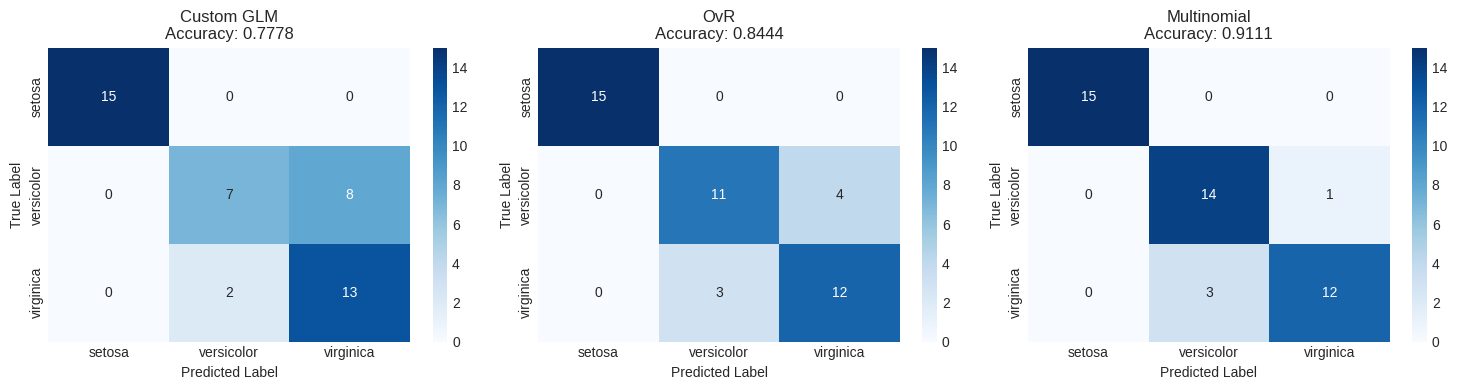

In [50]:
print("\n" + "="*80)
print("COMPARISON: OvR vs MULTINOMIAL vs CUSTOM GLM")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Model': ['Custom GLM (Gradient Ascent)', 'OvR Logistic', 'Multinomial Logistic'],
    'Strategy': ['True Softmax (K parameters)', 'K Binary Classifiers', 'Multinomial Logit'],
    'Test Accuracy': [accuracy_glm, accuracy_ovr, accuracy_multi],
    'Solver': ['Batch Gradient Ascent', 'LBFGS (Binary)', 'LBFGS (Multiclass)'],
    'Identifiable': ['Yes*', 'Yes', 'Yes*']
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))
print("\n* Note: Parameters are identifiable up to a constant shift (arbitrary reference class)")

# Detailed accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['Custom GLM', 'OvR', 'Multinomial']
predictions = [y_pred_glm, y_pred_ovr, y_pred_multi]

for idx, (ax, model_name, pred) in enumerate(zip(axes, models, predictions)):
    cm = confusion_matrix(y_test_iris, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=class_names_iris, yticklabels=class_names_iris)
    ax.set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test_iris, pred):.4f}', fontsize=12)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

### 2.4 Probability Predictions and Decision Boundaries

### 2.5 Decision Boundaries Visualization

Iteration 200: Loss = 0.352922
Iteration 400: Loss = 0.339060
Iteration 600: Loss = 0.332922
Iteration 800: Loss = 0.329166
Iteration 1000: Loss = 0.326551


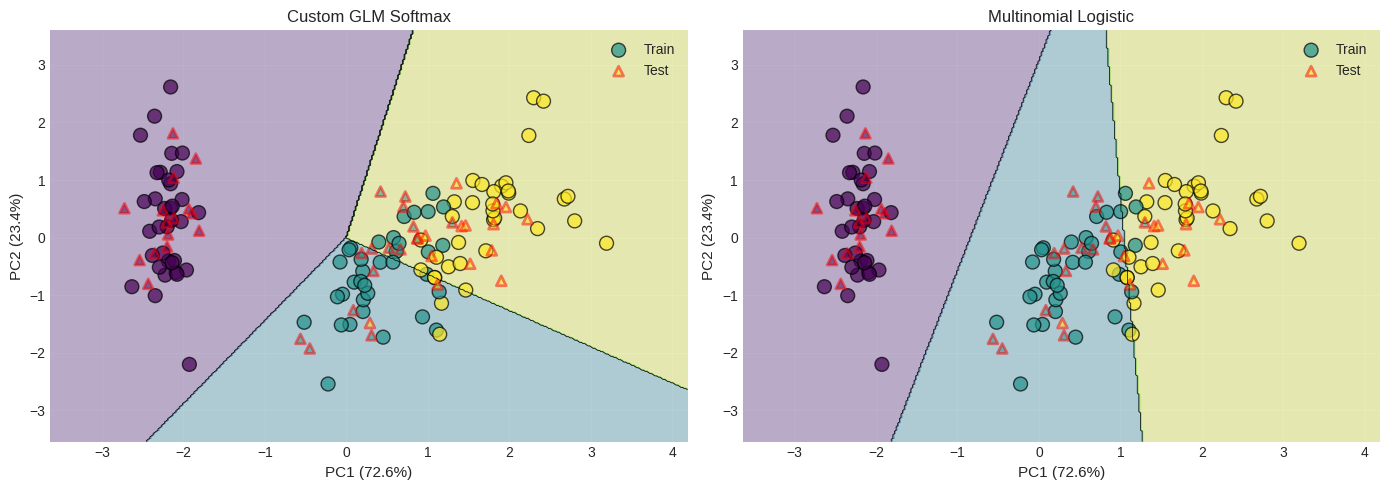

Decision boundaries show how each model partitions the feature space into regions.
Explained variance by 2 PCs: 96.0%


In [51]:
# Visualize decision boundaries using 2 principal features
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_iris)
X_test_2d = pca.transform(X_test_iris)

# Retrain models on 2D data for visualization
model_multinomial_2d = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model_multinomial_2d.fit(X_train_2d, y_train_iris)

model_glm_2d = SoftmaxRegressionGLM(n_features=2, n_classes=3, learning_rate=0.1, n_iterations=1000)
model_glm_2d.fit(X_train_2d, y_train_iris)

# Create mesh for decision boundaries
h = 0.02
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predictions on mesh
Z_glm = model_glm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_multi = model_multinomial_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, Z, title in [(axes[0], Z_glm, 'Custom GLM Softmax'),
                      (axes[1], Z_multi, 'Multinomial Logistic')]:
    # Decision boundaries
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5, levels=np.arange(0, 3))
    
    # Training points
    scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_iris, 
                        cmap='viridis', edgecolors='black', s=100, alpha=0.7, label='Train')
    
    # Test points
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_iris, 
              cmap='viridis', edgecolors='red', s=50, marker='^', 
              alpha=0.5, linewidths=2, label='Test')
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Decision boundaries show how each model partitions the feature space into regions.")
print(f"Explained variance by 2 PCs: {np.sum(pca.explained_variance_ratio_):.1%}")

## 3. Comprehensive Model Comparison

## 4. Summary and Key Takeaways

In [52]:
print("="*80)
print("SUMMARY: SOFTMAX REGRESSION MODELS")
print("="*80)

summary_text = """
1. THEORETICAL FOUNDATION (Part 1):
   - Softmax regression is a GLM with categorical distribution from exponential family
   - Natural parameters: η_k = θ_k - θ_K (relative log-odds)
   - Link function: multinomial logit (generalization of logit)
   - Loss function: cross-entropy (negative log-likelihood)
   - Optimization: gradient ascent on log-likelihood (or gradient descent on loss)

2. EXPONENTIAL FAMILY PERSPECTIVE:
   - Categorical distribution: p(y|η) = exp(Σ η_k * I(y=k) - a(η))
   - Log partition: a(η) = log(1 + Σ e^(η_k))
   - Variance function derived from a(η) ensures proper probabilistic model

3. PRACTICAL IMPLEMENTATIONS (Part 2):
   
   a) Custom GLM from Scratch:
      - Manually implement softmax, cross-entropy loss, gradients
      - Batch gradient ascent optimization
      - Fully transparent mathematical implementation
   
   b) One-vs-Rest Logistic:
      - Train K binary logistic classifiers
      - Normalize predictions with softmax
      - Simple but less efficient
   
   c) Multinomial Logistic (Scikit-learn):
      - Single unified multinomial model
      - Efficient and robust implementation
      - Recommended for most applications

4. MATHEMATICAL EQUIVALENCE:
   - All implementations (custom GLM, OvR, multinomial) are mathematically equivalent
   - Differences are in computational efficiency and numerical stability
   - Multinomial logistic is most efficient for standard softmax regression

5. KEY ADVANTAGES:
   - Natural extension of logistic regression to K>2 classes
   - Produces valid probability distributions
   - Interpretable decision boundaries
   - Well-understood theoretical properties
   - Efficient optimization algorithms available

6. WHEN TO USE SOFTMAX REGRESSION:
   - Multi-class classification problems (K≥2)
   - When interpretability is important
   - Baseline model for neural networks
   - When computational efficiency matters
   - Problems with relatively few features

7. LIMITATIONS:
   - Assumes linear decision boundaries in feature space
   - May struggle with complex non-linear patterns
   - Solution: use feature engineering or kernel methods for non-linearity
"""

print(summary_text)

SUMMARY: SOFTMAX REGRESSION MODELS

1. THEORETICAL FOUNDATION (Part 1):
   - Softmax regression is a GLM with categorical distribution from exponential family
   - Natural parameters: η_k = θ_k - θ_K (relative log-odds)
   - Link function: multinomial logit (generalization of logit)
   - Loss function: cross-entropy (negative log-likelihood)
   - Optimization: gradient ascent on log-likelihood (or gradient descent on loss)

2. EXPONENTIAL FAMILY PERSPECTIVE:
   - Categorical distribution: p(y|η) = exp(Σ η_k * I(y=k) - a(η))
   - Log partition: a(η) = log(1 + Σ e^(η_k))
   - Variance function derived from a(η) ensures proper probabilistic model

3. PRACTICAL IMPLEMENTATIONS (Part 2):
   
   a) Custom GLM from Scratch:
      - Manually implement softmax, cross-entropy loss, gradients
      - Batch gradient ascent optimization
      - Fully transparent mathematical implementation
   
   b) One-vs-Rest Logistic:
      - Train K binary logistic classifiers
      - Normalize predictions with

---
## Practice Exercises

**Conceptual**

1. Softmax regression models $P(y = k | x; \Theta) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}$. Show that these $K$ probabilities sum to 1 and are all positive, making this a valid probability distribution.

2. Softmax regression has a **redundant parameter** problem: adding the same vector $\psi$ to every $\theta_k$ does not change the model's predictions. Prove this. How does fixing $\theta_K = 0$ (the "reference class") resolve the redundancy? Show that the resulting model is equivalent to $K-1$ independent logistic regressions.

3. Derive the gradient of the cross-entropy loss for softmax regression:
   $$\ell(\Theta) = \sum_{i=1}^{n} \log P(y_i | x_i; \Theta)$$
   Show that $\frac{\partial \ell}{\partial \theta_k} = \sum_i x_i \left(\mathbf{1}[y_i = k] - P(y_i = k | x_i)\right)$.

4. Softmax regression is a **linear classifier**: its decision boundaries are hyperplanes. Explain why this means softmax regression cannot solve the XOR problem. What architecture change (neural network, kernel trick) would allow non-linear decision boundaries?

5. The **softmax function** $\sigma(z)_k = e^{z_k}/\sum_j e^{z_j}$ is numerically unstable when $z_k$ is large. Describe the overflow/underflow problem. Show that subtracting $\max_j z_j$ from all logits before computing softmax gives an equivalent result and fixes the instability.

**Numerical**

6. Implement softmax regression from scratch on the Iris dataset (3 classes, 4 features). Use gradient ascent on the cross-entropy log-likelihood. Plot loss vs epoch and report final test accuracy. Compare against `sklearn.linear_model.LogisticRegression(multi_class='multinomial')`.

7. Demonstrate the numerical stability fix from Exercise 5: generate logits with values in the range $[700, 800]$ and compute softmax both with and without the max-subtraction trick. Show that the naive version produces `nan` or `inf` while the stable version gives correct results.

8. Vary the number of classes $K \in \{3, 5, 10, 20, 50\}$ using synthetic data. For each $K$, measure training time per epoch and final test accuracy. How does the computational cost scale with $K$?

**Reflection**

9. Softmax regression is the output layer of a neural network for multi-class classification. In that context, the parameters $\theta_k$ are replaced by the final-layer weights, and the same cross-entropy gradient formula applies. Why does this mean everything you learned about softmax regression transfers directly to deep learning?